# **Task 4: Loan Default Risk with Business Cost Optimization**

## **1. Problem Statement and Objective**

### **Problem Statement**

Financial institutions must decide whether to approve or reject loan applications. A weak loan approval system can create serious business losses.

There are two major types of wrong decisions:

1. **False Positive**

   * The model predicts that a customer will default, but the customer would actually repay.
   * Business impact: the bank may reject a good customer and lose potential profit.

2. **False Negative**

   * The model predicts that a customer will repay, but the customer actually defaults.
   * Business impact: the bank approves a risky customer and suffers financial loss.

In loan default prediction, **false negatives are usually more costly than false positives** because lending money to a defaulter can create direct financial loss.

### **Objective**

The objective of this project is to:

1. Predict the likelihood of loan default using the **Home Credit Default Risk Dataset**.
2. Clean and preprocess the dataset.
3. Train binary classification models:

   * Logistic Regression
   * CatBoost Classifier
4. Evaluate model performance using classification metrics.
5. Define business cost values for false positives and false negatives.
6. Adjust the decision threshold to minimize total business cost.
7. Provide final insights and business recommendations.

---  

# **2. Install Required Libraries**  

## Install Libraries

In [1]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


---  

## Import Libraries

In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Machine learning models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# **3. Dataset Description and Loading**

### **Dataset Description**

The **Home Credit Default Risk Dataset** is used to predict whether a loan applicant is likely to default.

The main file used in this task is:

```text
application_train.csv
```

Important columns include:

| Column             | Description                                       |
| :----------------- | :------------------------------------------------ |
| SK_ID_CURR         | Unique customer/application ID                    |
| TARGET             | Target variable: 1 = default risk, 0 = no default |
| AMT_INCOME_TOTAL   | Applicant income                                  |
| AMT_CREDIT         | Loan credit amount                                |
| AMT_ANNUITY        | Loan annuity                                      |
| AMT_GOODS_PRICE    | Price of goods for which loan is given            |
| NAME_CONTRACT_TYPE | Type of loan                                      |
| CODE_GENDER        | Gender                                            |
| FLAG_OWN_CAR       | Whether applicant owns a car                      |
| FLAG_OWN_REALTY    | Whether applicant owns property                   |
| DAYS_BIRTH         | Applicant age in negative days                    |
| DAYS_EMPLOYED      | Employment duration in negative days              |
| CNT_CHILDREN       | Number of children                                |
| CNT_FAM_MEMBERS    | Number of family members                          |
| EXT_SOURCE_1/2/3   | External credit score sources                     |

The target variable is:

```text
TARGET
```

Where:

```text
0 = Non-default
1 = Default
```

---  

## Load Dataset

In [3]:
# Load the main training dataset
df = pd.read_csv("application_train.csv")

# Display first five rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---  

# **4. Initial Data Exploration**  

## Dataset Shape and Basic Information

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 81512
Number of columns: 122


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81512 entries, 0 to 81511
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(103), int64(3), object(16)
memory usage: 75.9+ MB


---  

## Statistical Summary

In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,81512.000000,81512.000000,81512.000000,8.151200e+04,8.151200e+04,81506.000000,8.144500e+04,81511.000000,81511.000000,81511.000000,...,81511.000000,81511.000000,81511.000000,81511.000000,70623.000000,70623.000000,70623.000000,70623.000000,70623.000000,70623.000000
mean,147268.595495,0.080675,0.417276,1.695310e+05,5.988731e+05,27085.685177,5.381350e+05,0.020847,-16034.013483,63396.170063,...,0.008318,0.000638,0.000429,0.000307,0.006825,0.007377,0.033346,0.269133,0.265976,1.888535
std,27254.675600,0.272337,0.723458,4.218768e+05,4.015644e+05,14459.308109,3.688656e+05,0.013795,4368.238056,140932.980028,...,0.090823,0.025250,0.020717,0.017510,0.087014,0.107040,0.200622,0.921946,0.613281,1.875227
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1980.000000,4.500000e+04,0.000533,-25201.000000,-17531.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,123773.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16501.500000,2.385000e+05,0.010006,-19675.000000,-2770.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,147199.000000,0.000000,0.000000,1.481895e+05,5.129978e+05,24903.000000,4.500000e+05,0.018850,-15760.000000,-1216.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,170894.250000,0.000000,1.000000,2.025000e+05,8.086500e+05,34587.000000,6.795000e+05,0.028663,-12381.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,194513.000000,1.000000,12.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7676.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,3.000000,6.000000,6.000000,24.000000,8.000000,25.000000


---  

## Target Variable Distribution

In [7]:
# Count target values
target_counts = df["TARGET"].value_counts()

target_counts

,count
TARGET,
0,74936
1,6576


In [8]:
# Percentage distribution
target_percentages = df["TARGET"].value_counts(normalize=True) * 100

target_percentages

,proportion
TARGET,
0,91.932476
1,8.067524


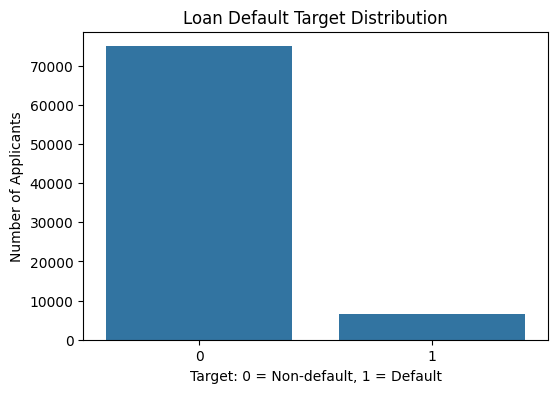

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="TARGET")
plt.title("Loan Default Target Distribution")
plt.xlabel("Target: 0 = Non-default, 1 = Default")
plt.ylabel("Number of Applicants")
plt.show()

### **Observation**

The dataset is usually highly imbalanced. Most customers do not default, while a smaller percentage default.

This means **accuracy alone is not reliable**. A model can get high accuracy by predicting most customers as non-default, but that would be dangerous for business decision-making.

---

# **5. Data Cleaning and Preprocessing**

---

## Check Missing Values

In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(20)

,0
COMMONAREA_AVG,56891
COMMONAREA_MODE,56891
COMMONAREA_MEDI,56891
NONLIVINGAPARTMENTS_MEDI,56520
NONLIVINGAPARTMENTS_MODE,56520
NONLIVINGAPARTMENTS_AVG,56520
LIVINGAPARTMENTS_AVG,55699
LIVINGAPARTMENTS_MODE,55699
LIVINGAPARTMENTS_MEDI,55699
FONDKAPREMONT_MODE,55642


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

missing_percentage.head(20)

,0
COMMONAREA_AVG,69.794631
COMMONAREA_MODE,69.794631
COMMONAREA_MEDI,69.794631
NONLIVINGAPARTMENTS_MEDI,69.339484
NONLIVINGAPARTMENTS_MODE,69.339484
NONLIVINGAPARTMENTS_AVG,69.339484
LIVINGAPARTMENTS_AVG,68.332270
LIVINGAPARTMENTS_MODE,68.332270
LIVINGAPARTMENTS_MEDI,68.332270
FONDKAPREMONT_MODE,68.262342


---  

## Visualize Missing Values

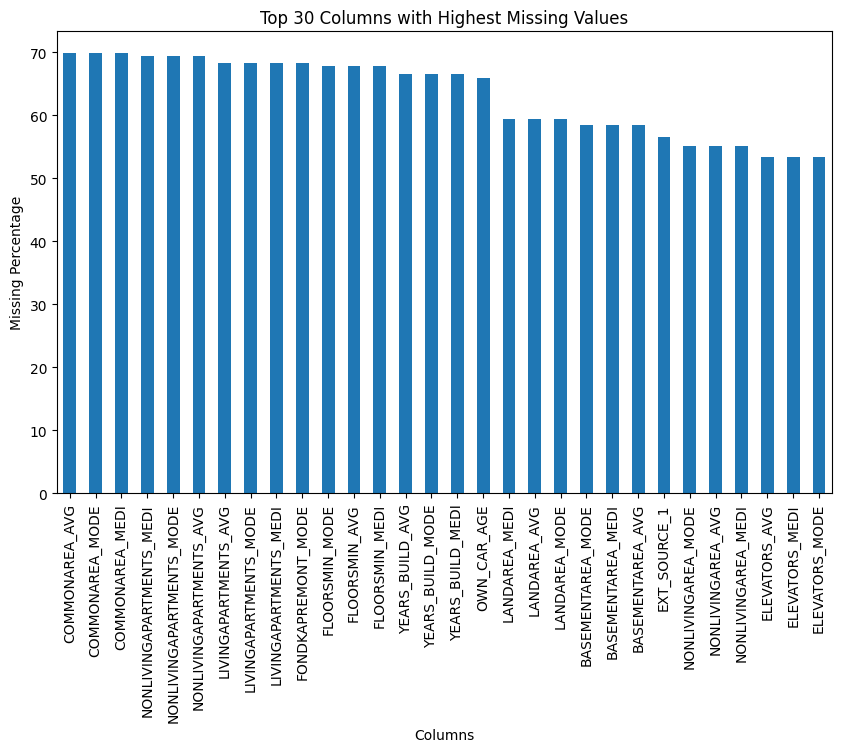

In [12]:
plt.figure(figsize=(10, 6))
missing_percentage.head(30).plot(kind="bar")
plt.title("Top 30 Columns with Highest Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")
plt.show()

---  

## Drop Columns with Very High Missing Values  

Columns with extremely high missing values can weaken model quality.  

Here, columns with more than **60% missing values** are removed.

In [13]:
# Define missing value threshold
missing_threshold = 60

# Identify columns to drop
columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

print("Number of columns to drop:", len(columns_to_drop))
print(columns_to_drop[:20])

Number of columns to drop: 17
['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE']


In [14]:
# Drop high-missing columns
df_cleaned = df.drop(columns=columns_to_drop)

print("Original shape:", df.shape)
print("Shape after dropping high-missing columns:", df_cleaned.shape)

Original shape: (81512, 122)
Shape after dropping high-missing columns: (81512, 105)


---  

## Remove ID Column  

The customer ID is only an identifier and does not help prediction.

In [15]:
# Drop customer ID column
if "SK_ID_CURR" in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=["SK_ID_CURR"])

df_cleaned.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---  

## Fix Anomalous Employment Values  

In this dataset, `DAYS_EMPLOYED` sometimes contains the abnormal value `365243`.  

This usually represents missing or unknown employment duration.

In [16]:
# Check DAYS_EMPLOYED abnormal values
if "DAYS_EMPLOYED" in df_cleaned.columns:
    print(df_cleaned["DAYS_EMPLOYED"].describe())
    print("Number of abnormal values:", (df_cleaned["DAYS_EMPLOYED"] == 365243).sum())

count     81511.000000
mean      63396.170063
std      140932.980028
min      -17531.000000
25%       -2770.000000
50%       -1216.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64
Number of abnormal values: 14586


In [17]:
# Replace abnormal DAYS_EMPLOYED value with NaN
if "DAYS_EMPLOYED" in df_cleaned.columns:
    df_cleaned["DAYS_EMPLOYED"] = df_cleaned["DAYS_EMPLOYED"].replace(365243, np.nan)

---  

## Create Useful Features  

The original dataset contains some values in negative days.  
We convert them into more interpretable features.

In [18]:
# Convert DAYS_BIRTH into age in years
if "DAYS_BIRTH" in df_cleaned.columns:
    df_cleaned["AGE_YEARS"] = (-df_cleaned["DAYS_BIRTH"]) / 365

# Convert DAYS_EMPLOYED into employment years
if "DAYS_EMPLOYED" in df_cleaned.columns:
    df_cleaned["EMPLOYED_YEARS"] = (-df_cleaned["DAYS_EMPLOYED"]) / 365

# Credit to income ratio
if "AMT_CREDIT" in df_cleaned.columns and "AMT_INCOME_TOTAL" in df_cleaned.columns:
    df_cleaned["CREDIT_INCOME_RATIO"] = df_cleaned["AMT_CREDIT"] / (df_cleaned["AMT_INCOME_TOTAL"] + 1)

# Annuity to income ratio
if "AMT_ANNUITY" in df_cleaned.columns and "AMT_INCOME_TOTAL" in df_cleaned.columns:
    df_cleaned["ANNUITY_INCOME_RATIO"] = df_cleaned["AMT_ANNUITY"] / (df_cleaned["AMT_INCOME_TOTAL"] + 1)

# Credit to goods price ratio
if "AMT_CREDIT" in df_cleaned.columns and "AMT_GOODS_PRICE" in df_cleaned.columns:
    df_cleaned["CREDIT_GOODS_RATIO"] = df_cleaned["AMT_CREDIT"] / (df_cleaned["AMT_GOODS_PRICE"] + 1)

df_cleaned.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,0.0,1.0,25.920548,1.745205,2.007879,0.121977,1.158394
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,0.0,0.0,45.931507,3.254795,4.790732,0.132216,1.145198
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,0.0,0.0,52.180822,0.616438,1.999970,0.099999,0.999993
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,NaN,NaN,NaN,NaN,NaN,52.068493,8.326027,2.316150,0.219898,1.052799
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,0.0,0.0,54.608219,8.323288,4.222187,0.179961,0.999998


---

# **6. Exploratory Data Analysis**

---

## Default Rate by Gender

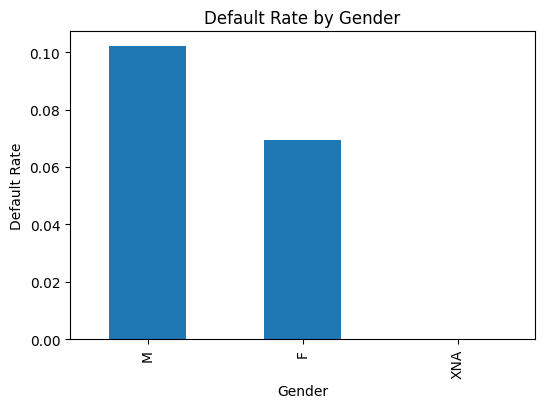

In [19]:
if "CODE_GENDER" in df_cleaned.columns:
    gender_default = df_cleaned.groupby("CODE_GENDER")["TARGET"].mean().sort_values(ascending=False)

    plt.figure(figsize=(6, 4))
    gender_default.plot(kind="bar")
    plt.title("Default Rate by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Default Rate")
    plt.show()

    gender_default

---  

## Age Distribution by Default Status

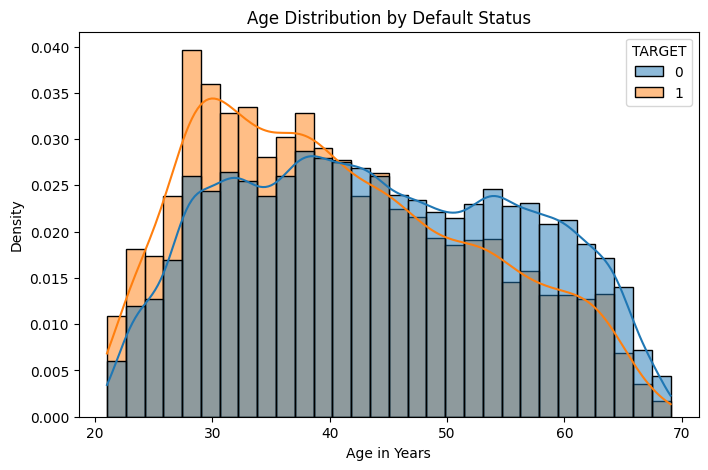

In [20]:
if "AGE_YEARS" in df_cleaned.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df_cleaned,
        x="AGE_YEARS",
        hue="TARGET",
        bins=30,
        kde=True,
        stat="density",
        common_norm=False
    )
    plt.title("Age Distribution by Default Status")
    plt.xlabel("Age in Years")
    plt.ylabel("Density")
    plt.show()

---  

## Income Distribution by Default Status

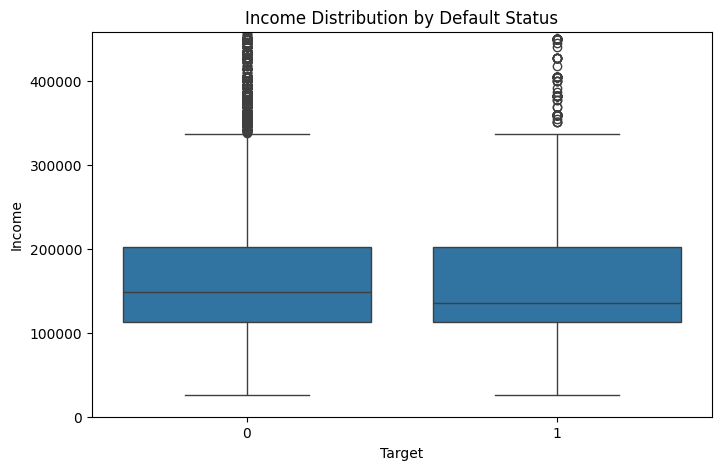

In [21]:
if "AMT_INCOME_TOTAL" in df_cleaned.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_cleaned,
        x="TARGET",
        y="AMT_INCOME_TOTAL"
    )
    plt.title("Income Distribution by Default Status")
    plt.xlabel("Target")
    plt.ylabel("Income")
    plt.ylim(0, df_cleaned["AMT_INCOME_TOTAL"].quantile(0.99))
    plt.show()

---  

## Credit Amount Distribution by Default Status

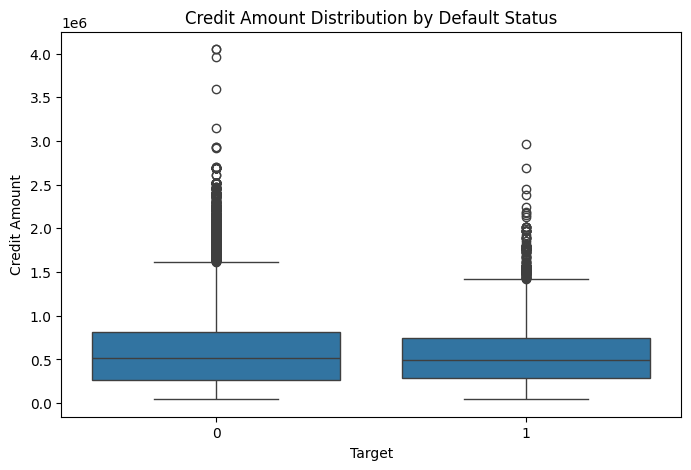

In [22]:
if "AMT_CREDIT" in df_cleaned.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_cleaned,
        x="TARGET",
        y="AMT_CREDIT"
    )
    plt.title("Credit Amount Distribution by Default Status")
    plt.xlabel("Target")
    plt.ylabel("Credit Amount")
    plt.show()

---  

## Credit-to-Income Ratio by Default Status

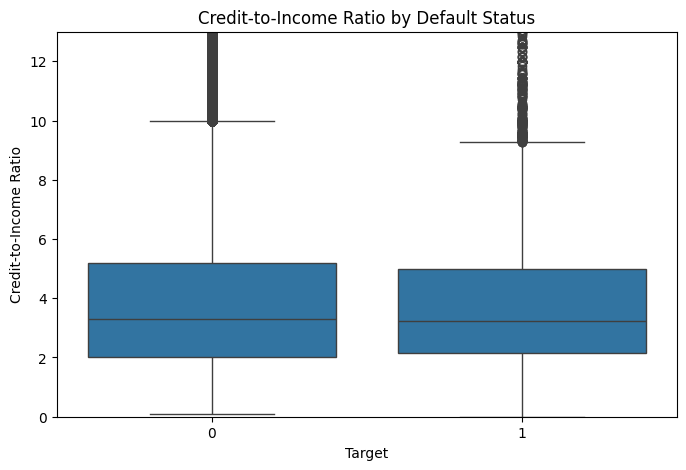

In [23]:
if "CREDIT_INCOME_RATIO" in df_cleaned.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_cleaned,
        x="TARGET",
        y="CREDIT_INCOME_RATIO"
    )
    plt.title("Credit-to-Income Ratio by Default Status")
    plt.xlabel("Target")
    plt.ylabel("Credit-to-Income Ratio")
    plt.ylim(0, df_cleaned["CREDIT_INCOME_RATIO"].quantile(0.99))
    plt.show()

---  

## Correlation with Target

In [24]:
# Select numerical columns
numeric_cols_for_corr = df_cleaned.select_dtypes(include=["int64", "float64"]).columns

# Calculate correlation with target
target_corr = df_cleaned[numeric_cols_for_corr].corr()["TARGET"].sort_values(ascending=False)

target_corr.head(15)

,TARGET
TARGET,1.000000
DAYS_BIRTH,0.077413
DAYS_EMPLOYED,0.075270
CREDIT_GOODS_RATIO,0.068698
REGION_RATING_CLIENT,0.063089
REGION_RATING_CLIENT_W_CITY,0.062666
DAYS_LAST_PHONE_CHANGE,0.054221
DAYS_ID_PUBLISH,0.049636
REG_CITY_NOT_WORK_CITY,0.048293
FLAG_DOCUMENT_3,0.044227


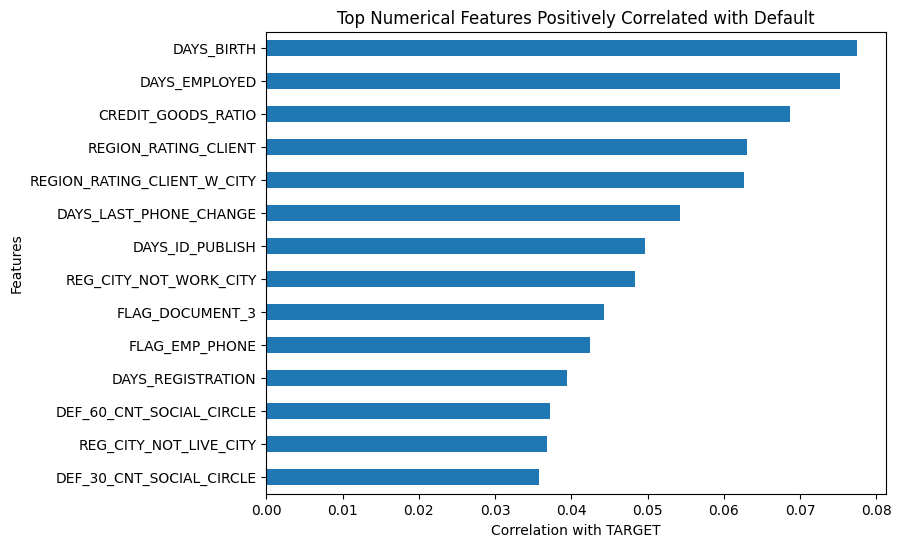

In [25]:
plt.figure(figsize=(8, 6))
target_corr.head(15).drop("TARGET").plot(kind="barh")
plt.title("Top Numerical Features Positively Correlated with Default")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

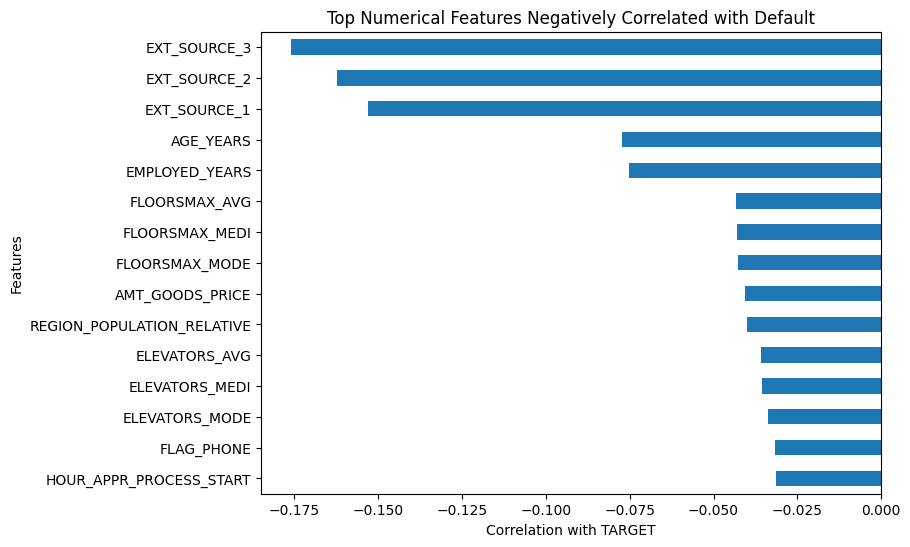

In [26]:
plt.figure(figsize=(8, 6))
target_corr.tail(15).plot(kind="barh")
plt.title("Top Numerical Features Negatively Correlated with Default")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Features")
plt.show()

---

# **7. Prepare Data for Modeling**

---

## Separate Features and Target

In [27]:
# Separate target and features
X = df_cleaned.drop(columns=["TARGET"])
y = df_cleaned["TARGET"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (81512, 108)
Target dataset shape: (81512,)


---  

## Identify Categorical and Numerical Features

In [28]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Number of categorical features: 15
Number of numerical features: 93


---  

## Train-Test Split

In [29]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True))

Training features: (65209, 108)
Testing features: (16303, 108)
Training target distribution:
TARGET
0    0.919321
1    0.080679
Name: proportion, dtype: float64
Testing target distribution:
TARGET
0    0.91934
1    0.08066
Name: proportion, dtype: float64


---

# **8. Model 1 — Logistic Regression**

Logistic Regression needs:

1. Missing value handling
2. Feature scaling for numerical variables
3. One-hot encoding for categorical variables

---

## Preprocessing for Logistic Regression

In [30]:
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

---  

## Train Logistic Regression Model

In [31]:
# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train model
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'FLAG_MOBIL'...
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE',
                                                   'HOUSETYPE_MODE',
                                                   'WALLSMATERIAL_MODE',
                                                   'EMERGENCYSTATE_MODE'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

---  

## Logistic Regression Predictions

In [32]:
# Predict class labels
logistic_pred = logistic_model.predict(X_test)

# Predict probabilities for default class
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

---  

## Evaluate Logistic Regression

In [33]:
print("Logistic Regression Evaluation")
print("=" * 50)

print("Accuracy:", round(accuracy_score(y_test, logistic_pred), 4))
print("F1 Score:", round(f1_score(y_test, logistic_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, logistic_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Logistic Regression Evaluation
Accuracy: 0.6891
F1 Score: 0.2509
ROC-AUC: 0.7346

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     14988
           1       0.16      0.65      0.25      1315

    accuracy                           0.69     16303
   macro avg       0.56      0.67      0.53     16303
weighted avg       0.89      0.69      0.76     16303



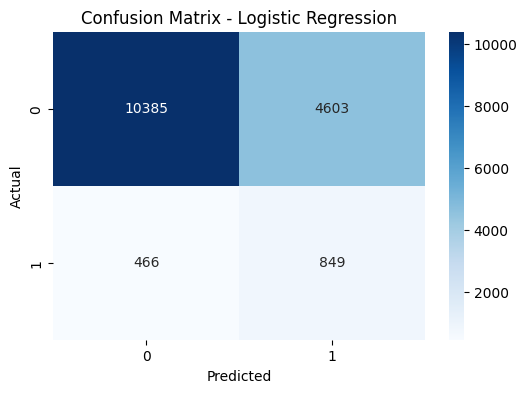

In [34]:
# Confusion matrix
cm_logistic = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---

# **9. Model 2 — CatBoost Classifier**

CatBoost is strong for tabular data and handles categorical features well.

For CatBoost, we will:

1. Fill missing categorical values with `"Missing"`.
2. Fill missing numerical values with median.
3. Pass categorical feature names directly to CatBoost.

---

## Prepare Data for CatBoost

In [35]:
# Create copies for CatBoost
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

# Fill categorical missing values
for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].fillna("Missing")
    X_test_cat[col] = X_test_cat[col].fillna("Missing")

# Fill numerical missing values
for col in numerical_features:
    median_value = X_train_cat[col].median()
    X_train_cat[col] = X_train_cat[col].fillna(median_value)
    X_test_cat[col] = X_test_cat[col].fillna(median_value)

# CatBoost categorical feature indices
cat_feature_indices = [
    X_train_cat.columns.get_loc(col)
    for col in categorical_features
]

print("Number of categorical features for CatBoost:", len(cat_feature_indices))

Number of categorical features for CatBoost: 15


---  

## Train CatBoost Model

In [36]:
# Initialize CatBoost model
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 5],
    random_seed=42,
    verbose=100
)

# Train model
catboost_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test_cat, y_test),
    use_best_model=True
)

0:	test: 0.6508917	best: 0.6508917 (0)	total: 304ms	remaining: 2m 31s
100:	test: 0.7432133	best: 0.7432133 (100)	total: 25s	remaining: 1m 38s
200:	test: 0.7461358	best: 0.7461358 (200)	total: 48.1s	remaining: 1m 11s
300:	test: 0.7483079	best: 0.7483079 (300)	total: 1m 15s	remaining: 49.8s
400:	test: 0.7479833	best: 0.7486253 (343)	total: 1m 41s	remaining: 25.1s
499:	test: 0.7483978	best: 0.7486253 (343)	total: 2m 6s	remaining: 0us

bestTest = 0.7486252627
bestIteration = 343

Shrink model to first 344 iterations.


CatBoostClassifier(class_weights=[1, 5], depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

---  

## CatBoost Predictions

In [37]:
# Predict class labels using default threshold 0.5
catboost_pred = catboost_model.predict(X_test_cat)

# Predict probabilities for default class
catboost_prob = catboost_model.predict_proba(X_test_cat)[:, 1]

---  

## Evaluate CatBoost

In [38]:
print("CatBoost Evaluation")
print("=" * 50)

print("Accuracy:", round(accuracy_score(y_test, catboost_pred), 4))
print("F1 Score:", round(f1_score(y_test, catboost_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, catboost_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, catboost_pred))

CatBoost Evaluation
Accuracy: 0.8771
F1 Score: 0.2899
ROC-AUC: 0.7486

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     14988
           1       0.27      0.31      0.29      1315

    accuracy                           0.88     16303
   macro avg       0.61      0.62      0.61     16303
weighted avg       0.88      0.88      0.88     16303



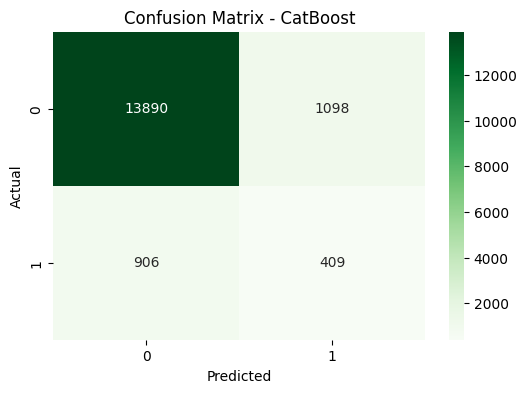

In [39]:
# Confusion matrix
cm_catboost = confusion_matrix(y_test, catboost_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_catboost, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Plot ROC Curves

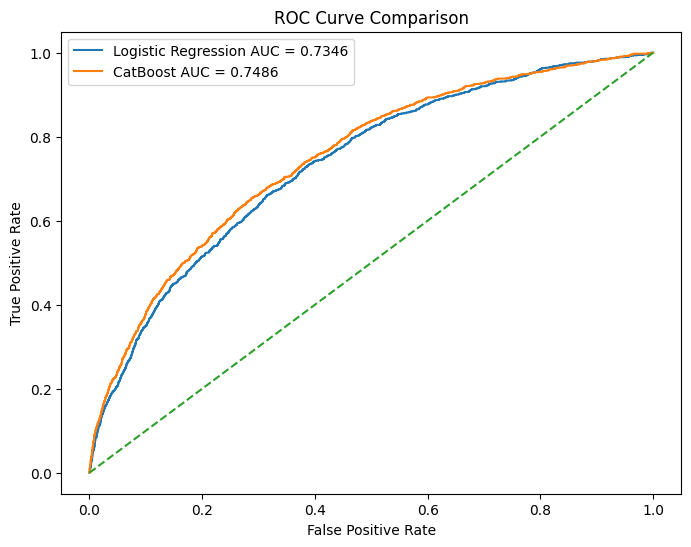

In [40]:
# ROC curve for Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)

# ROC curve for CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, catboost_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression AUC = {roc_auc_score(y_test, logistic_prob):.4f}"
)

plt.plot(
    fpr_cat,
    tpr_cat,
    label=f"CatBoost AUC = {roc_auc_score(y_test, catboost_prob):.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

---  

# **11. Precision-Recall Curve Comparison**  

For imbalanced loan default datasets, the Precision-Recall curve is often more useful than accuracy.  

## Plot Precision-Recall Curves

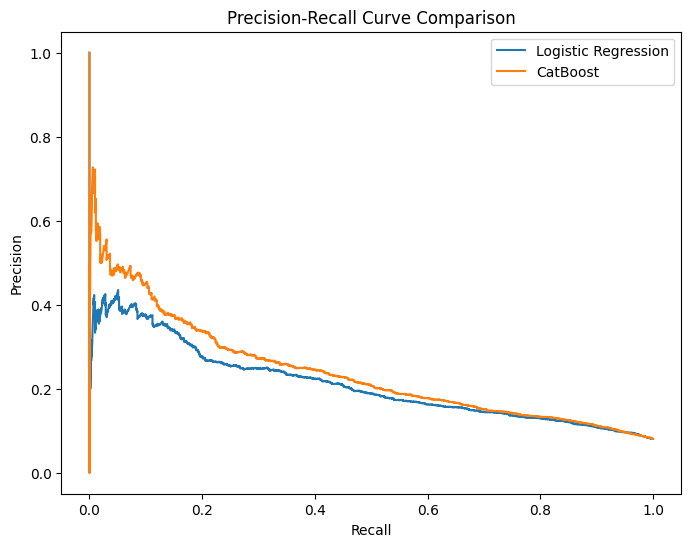

In [41]:
# Precision-recall values
precision_log, recall_log, _ = precision_recall_curve(y_test, logistic_prob)
precision_cat, recall_cat, _ = precision_recall_curve(y_test, catboost_prob)

plt.figure(figsize=(8, 6))

plt.plot(recall_log, precision_log, label="Logistic Regression")
plt.plot(recall_cat, precision_cat, label="CatBoost")

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

---

# **12. Business Cost Optimization**

---

## **Business Logic**

In this task, we define costs for wrong predictions.

### **False Positive Cost**

The model predicts the customer will default, but the customer would actually repay.

Business meaning:

```text
Rejecting a good customer.
```

Possible cost:

```text
Lost profit from interest income.
```

### **False Negative Cost**

The model predicts the customer will repay, but the customer actually defaults.

Business meaning:

```text
Approving a risky customer.
```

Possible cost:

```text
Loan loss, recovery cost, collection cost, and capital risk.
```

Since false negatives are more damaging, their cost should be higher.

For this project, we use the following assumed costs:

| Error Type     | Business Meaning          | Assumed Cost |
| :------------- | :------------------------ | :----------- |
| False Positive | Rejecting a good customer | 1,000        |
| False Negative | Approving a defaulter     | 10,000       |

These values are assumptions. In a real bank, they should be estimated using actual profit margins, loss given default, recovery rates, and operational costs.

---

## Define Business Costs

In [42]:
# Business cost assumptions
false_positive_cost = 1000
false_negative_cost = 10000

print("False Positive Cost:", false_positive_cost)
print("False Negative Cost:", false_negative_cost)

False Positive Cost: 1000
False Negative Cost: 10000


---  

## Create Cost Function

In [43]:
def calculate_business_cost(y_true, y_prob, threshold, fp_cost, fn_cost):
    """
    Calculate total business cost at a given probability threshold.

    Parameters:
    y_true: actual target values
    y_prob: predicted probabilities for default class
    threshold: decision threshold
    fp_cost: cost of false positive
    fn_cost: cost of false negative

    Returns:
    total_cost, false_positives, false_negatives, confusion matrix values
    """

    # Convert probabilities into class predictions based on threshold
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()

    # Calculate total cost
    total_cost = (fp * fp_cost) + (fn * fn_cost)

    return total_cost, fp, fn, tn, tp

---  

## Test Business Cost at Default Threshold 0.50

In [44]:
default_threshold = 0.50

default_cost, default_fp, default_fn, default_tn, default_tp = calculate_business_cost(
    y_test,
    catboost_prob,
    default_threshold,
    false_positive_cost,
    false_negative_cost
)

print("Business Cost at Threshold 0.50")
print("=" * 50)
print("Total Cost:", default_cost)
print("False Positives:", default_fp)
print("False Negatives:", default_fn)
print("True Negatives:", default_tn)
print("True Positives:", default_tp)

Business Cost at Threshold 0.50
Total Cost: 10158000
False Positives: 1098
False Negatives: 906
True Negatives: 13890
True Positives: 409


---

# **13. Threshold Optimization**

Instead of blindly using threshold `0.50`, we test many thresholds and choose the one with the lowest total business cost.

---

## Search for Best Threshold

In [45]:
# Threshold values to test
thresholds = np.arange(0.01, 1.00, 0.01)

cost_results = []

for threshold in thresholds:
    total_cost, fp, fn, tn, tp = calculate_business_cost(
        y_test,
        catboost_prob,
        threshold,
        false_positive_cost,
        false_negative_cost
    )

    cost_results.append({
        "threshold": threshold,
        "total_cost": total_cost,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "true_positives": tp
    })

# Convert to dataframe
cost_df = pd.DataFrame(cost_results)

# Find threshold with minimum cost
best_threshold_row = cost_df.loc[cost_df["total_cost"].idxmin()]
best_threshold_row

,30
threshold,0.31
total_cost,8876000.00
false_positives,4026.00
false_negatives,485.00
true_negatives,10962.00
true_positives,830.00


---  

## Best Threshold Summary

In [46]:
best_threshold = best_threshold_row["threshold"]
minimum_cost = best_threshold_row["total_cost"]

print("Best Threshold:", round(best_threshold, 2))
print("Minimum Business Cost:", int(minimum_cost))
print("False Positives at Best Threshold:", int(best_threshold_row["false_positives"]))
print("False Negatives at Best Threshold:", int(best_threshold_row["false_negatives"]))
print("True Negatives at Best Threshold:", int(best_threshold_row["true_negatives"]))
print("True Positives at Best Threshold:", int(best_threshold_row["true_positives"]))

Best Threshold: 0.31
Minimum Business Cost: 8876000
False Positives at Best Threshold: 4026
False Negatives at Best Threshold: 485
True Negatives at Best Threshold: 10962
True Positives at Best Threshold: 830


---  

## Plot Threshold vs Total Business Cost

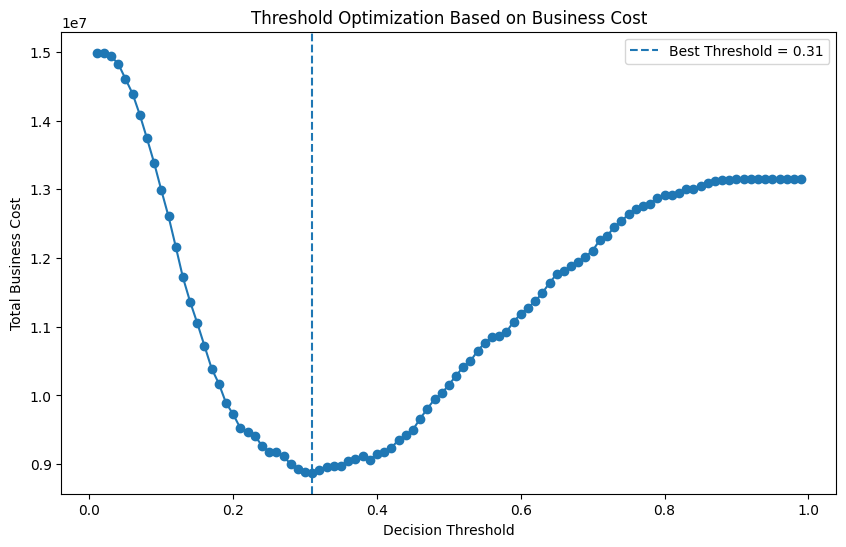

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(
    cost_df["threshold"],
    cost_df["total_cost"],
    marker="o"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.title("Threshold Optimization Based on Business Cost")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")
plt.legend()
plt.show()

---  

## False Positives and False Negatives by Threshold

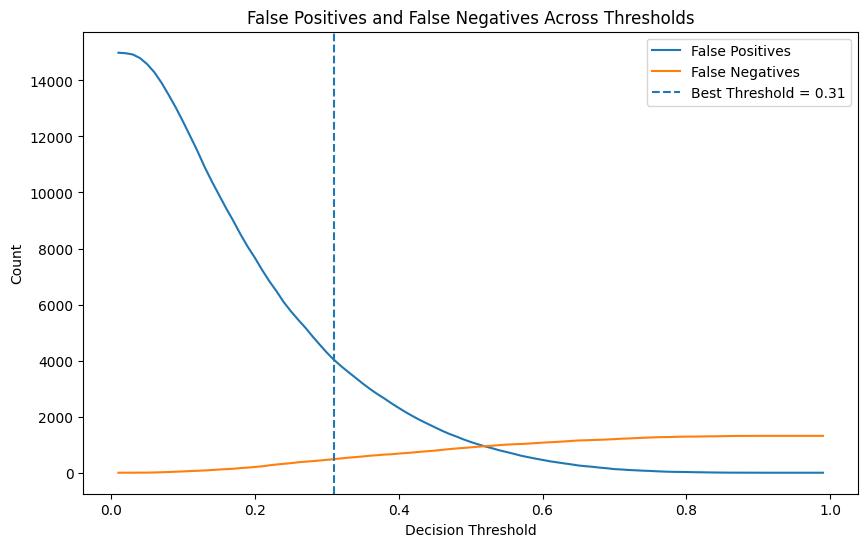

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    cost_df["threshold"],
    cost_df["false_positives"],
    label="False Positives"
)

plt.plot(
    cost_df["threshold"],
    cost_df["false_negatives"],
    label="False Negatives"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.title("False Positives and False Negatives Across Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Count")
plt.legend()
plt.show()

---

# **14. Evaluate CatBoost at Optimized Threshold**

---

## Predictions Using Optimized Threshold

In [49]:
# Create predictions using optimized threshold
catboost_pred_optimized = (catboost_prob >= best_threshold).astype(int)

---  

## Confusion Matrix at Optimized Threshold

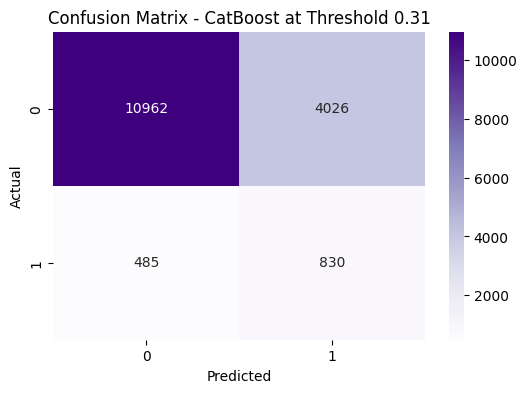

In [50]:
cm_optimized = confusion_matrix(y_test, catboost_pred_optimized)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_optimized, annot=True, fmt="d", cmap="Purples")
plt.title(f"Confusion Matrix - CatBoost at Threshold {best_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---  

## Classification Report at Optimized Threshold

In [51]:
print("CatBoost Evaluation at Optimized Threshold")
print("=" * 50)

print("Accuracy:", round(accuracy_score(y_test, catboost_pred_optimized), 4))
print("F1 Score:", round(f1_score(y_test, catboost_pred_optimized), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, catboost_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, catboost_pred_optimized))

CatBoost Evaluation at Optimized Threshold
Accuracy: 0.7233
F1 Score: 0.269
ROC-AUC: 0.7486

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     14988
           1       0.17      0.63      0.27      1315

    accuracy                           0.72     16303
   macro avg       0.56      0.68      0.55     16303
weighted avg       0.89      0.72      0.78     16303



---  

## Compare Default vs Optimized Threshold

In [52]:
# Cost at optimized threshold
optimized_cost, optimized_fp, optimized_fn, optimized_tn, optimized_tp = calculate_business_cost(
    y_test,
    catboost_prob,
    best_threshold,
    false_positive_cost,
    false_negative_cost
)

threshold_comparison = pd.DataFrame({
    "Threshold Type": ["Default Threshold", "Optimized Threshold"],
    "Threshold": [0.50, best_threshold],
    "Total Cost": [default_cost, optimized_cost],
    "False Positives": [default_fp, optimized_fp],
    "False Negatives": [default_fn, optimized_fn],
    "True Positives": [default_tp, optimized_tp],
    "True Negatives": [default_tn, optimized_tn]
})

threshold_comparison

,Threshold Type,Threshold,Total Cost,False Positives,False Negatives,True Positives,True Negatives
0,Default Threshold,0.50,10158000,1098,906,409,13890
1,Optimized Threshold,0.31,8876000,4026,485,830,10962


---  

## Plot Cost Comparison

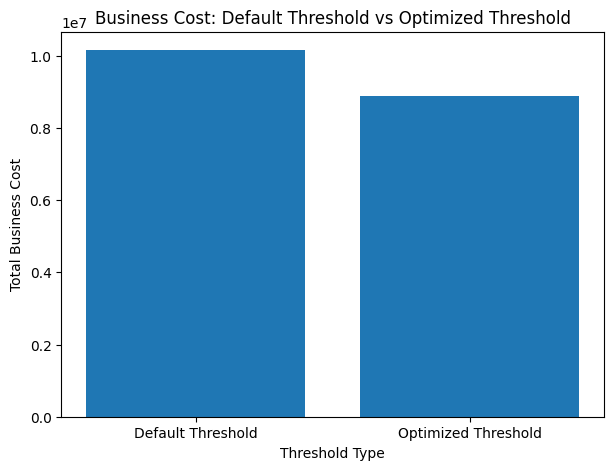

In [53]:
plt.figure(figsize=(7, 5))

plt.bar(
    threshold_comparison["Threshold Type"],
    threshold_comparison["Total Cost"]
)

plt.title("Business Cost: Default Threshold vs Optimized Threshold")
plt.xlabel("Threshold Type")
plt.ylabel("Total Business Cost")
plt.show()

## CatBoost Feature Importance

In [54]:
# Get feature importance from CatBoost
feature_importance = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": catboost_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
40,EXT_SOURCE_3,12.521433
39,EXT_SOURCE_2,9.990744
38,EXT_SOURCE_1,5.996246
107,CREDIT_GOODS_RATIO,4.075431
7,AMT_ANNUITY,3.230534
8,AMT_GOODS_PRICE,2.899458
11,NAME_EDUCATION_TYPE,2.832639
5,AMT_INCOME_TOTAL,2.715252
1,CODE_GENDER,2.524313
18,DAYS_ID_PUBLISH,2.504301


---  

## Plot Top 20 Important Features

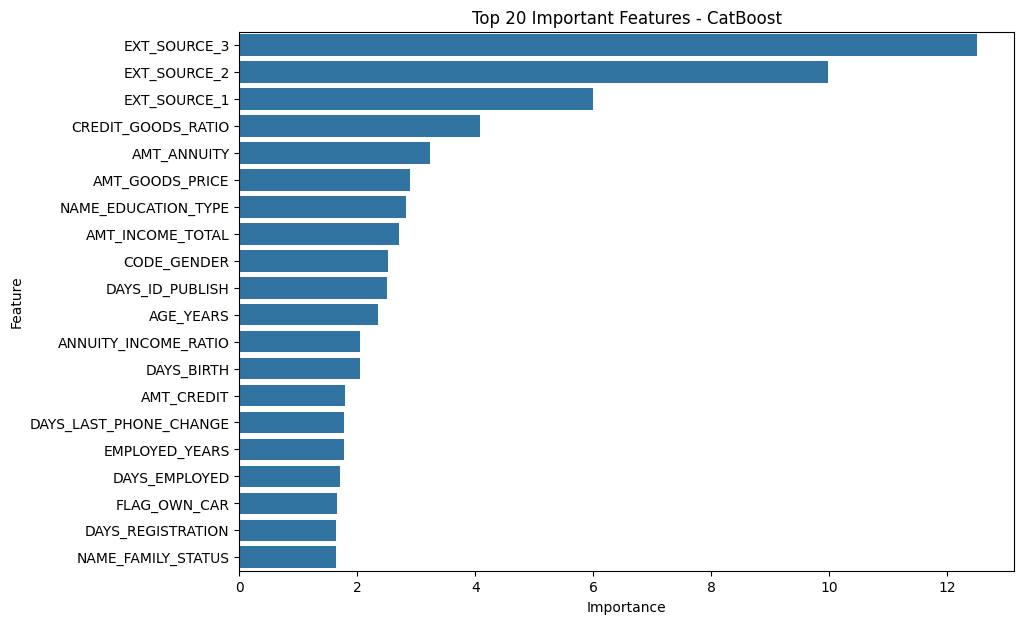

In [55]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features - CatBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Create Final Prediction Dataset

In [56]:
final_predictions = X_test.copy()

final_predictions["actual_default"] = y_test.values
final_predictions["predicted_probability_default"] = catboost_prob
final_predictions["prediction_threshold_0_50"] = catboost_pred
final_predictions["prediction_optimized_threshold"] = catboost_pred_optimized

final_predictions.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,actual_default,predicted_probability_default,prediction_threshold_0_50,prediction_optimized_threshold
53308,Cash loans,F,N,Y,0,90000.0,119925.0,13045.5,112500.0,Unaccompanied,...,5.0,54.147945,NaN,1.332485,0.144948,1.065991,0,0.043550,0,0
38988,Cash loans,F,N,Y,0,315000.0,1174005.0,78903.0,1125000.0,Unaccompanied,...,0.0,49.284932,0.756164,3.726988,0.250485,1.043559,0,0.075214,0,0
48979,Cash loans,F,N,N,0,54000.0,808650.0,26086.5,675000.0,Unaccompanied,...,0.0,45.698630,16.572603,14.974723,0.483074,1.197998,0,0.128344,0,0
42035,Cash loans,M,Y,N,0,112500.0,273636.0,14031.0,247500.0,Unaccompanied,...,0.0,60.227397,NaN,2.432298,0.124719,1.105596,0,0.129663,0,0
69425,Cash loans,F,N,N,1,292500.0,288562.5,30748.5,261000.0,Family,...,3.0,30.558904,7.915068,0.986535,0.105123,1.105599,0,0.472047,0,1


## Final Conclusion

This project predicted loan default risk using the Home Credit Default Risk Dataset and optimized the
classification threshold using business cost analysis.

The dataset was cleaned by handling missing values, removing columns with very high missing percentages,
fixing abnormal employment values, and creating useful financial features such as credit-to-income ratio,
annuity-to-income ratio, age in years, and employment years.

Exploratory Data Analysis showed that the target variable is imbalanced, meaning most applicants do not
default while a smaller percentage do default. Because of this imbalance, accuracy alone is not a reliable
metric. ROC-AUC, F1-score, confusion matrix, and business cost are more useful for evaluating the model.

Two models were trained:

1. Logistic Regression:
   This model served as a simple and interpretable baseline. It required scaling, missing value imputation,
   and one-hot encoding of categorical variables.

2. CatBoost Classifier:
   CatBoost was used as a stronger model for tabular data. It handled categorical features effectively and
   produced probability estimates for default risk.

A business cost function was created using assumed costs:
- False Positive Cost: rejecting a good customer
- False Negative Cost: approving a customer who defaults

Since false negatives create larger financial losses, the false negative cost was set higher than the false
positive cost.

The default threshold of 0.50 was compared with multiple alternative thresholds. The optimal threshold was
selected based on the minimum total business cost.

The optimized threshold reduced total business cost by balancing the trade-off between false positives and
false negatives. In loan default prediction, this is more practical than using the default 0.50 threshold.

Key business insight:

A model should not only be judged by accuracy. In financial risk problems, the cost of each mistake matters.
The best decision threshold is the one that minimizes expected business loss, not necessarily the one that
maximizes accuracy.

Overall, the CatBoost model combined with business cost optimization provides a more realistic loan approval
decision framework for financial institutions.